In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_csv("../data/processed/heart_clean.csv")
print("Loaded:", df.shape)
df.head()

Loaded: (270, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


C:\Users\NLP\AppData\Local\Temp\ipykernel_17264\2925700346.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=col, ax=axes[i],
C:\Users\NLP\AppData\Local\Temp\ipykernel_17264\2925700346.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(["No Disease", "Disease"])
C:\Users\NLP\AppData\Local\Temp\ipykernel_17264\2925700346.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=col, ax=axes[i],
C:\Users\NLP\AppData\Local\Temp\ipykernel_17264\2925700346.py:10: UserWarning: set_ticklabels() should only be us

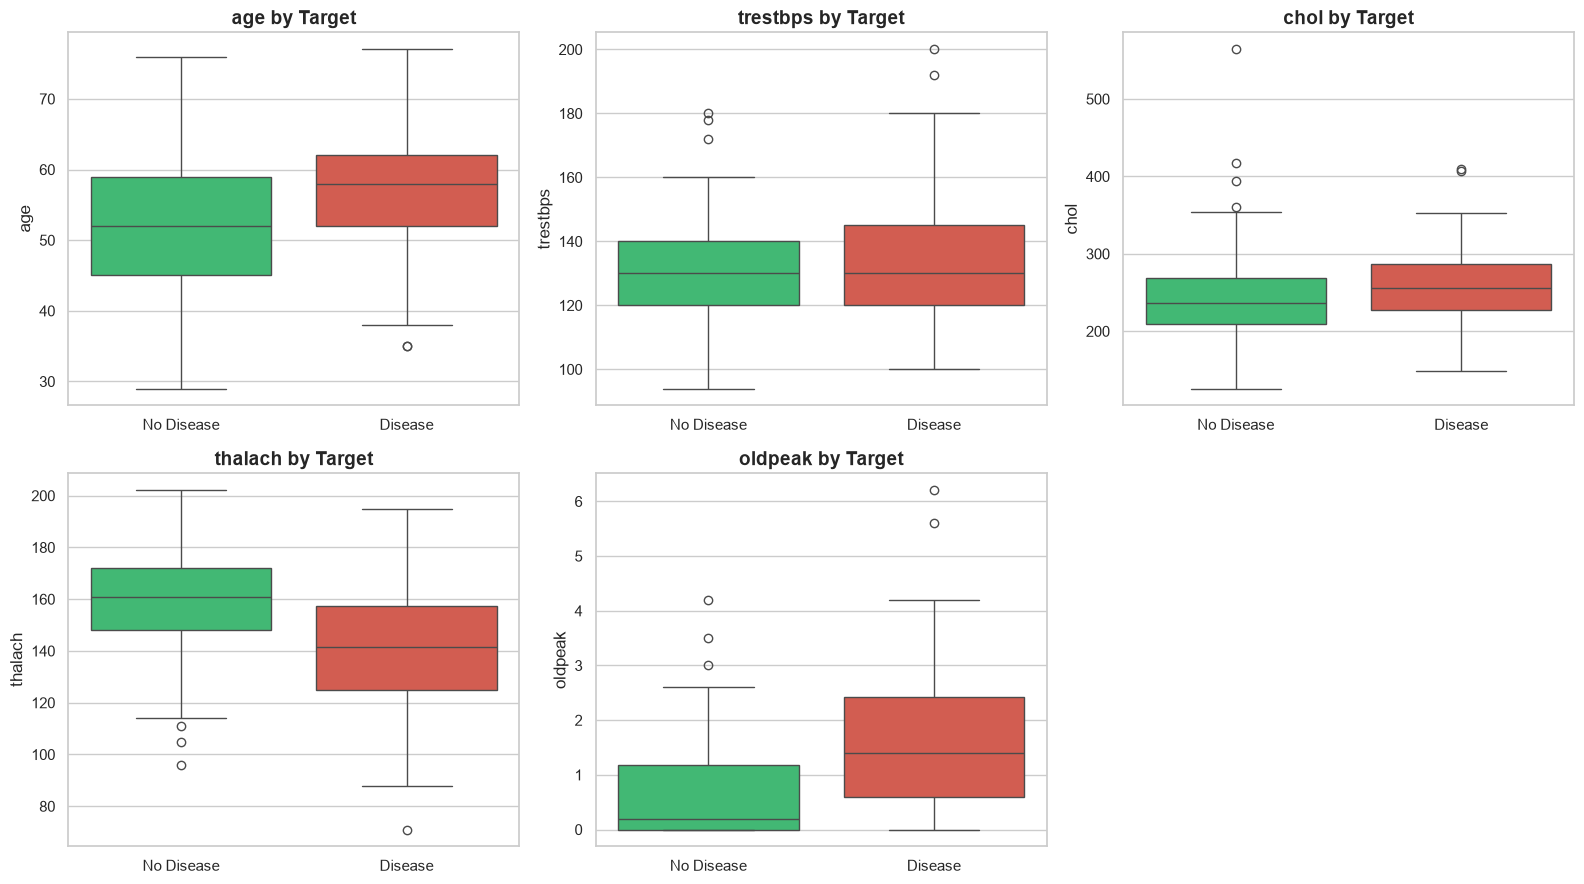

In [2]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="target", y=col, ax=axes[i],
                palette=["#2ecc71", "#e74c3c"])
    axes[i].set_title(f"{col} by Target")
    axes[i].set_xticklabels(["No Disease", "Disease"])
    axes[i].set_xlabel("")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig("../reports/figures/05_numeric_vs_target_box.png", dpi=150, bbox_inches="tight")
plt.show()

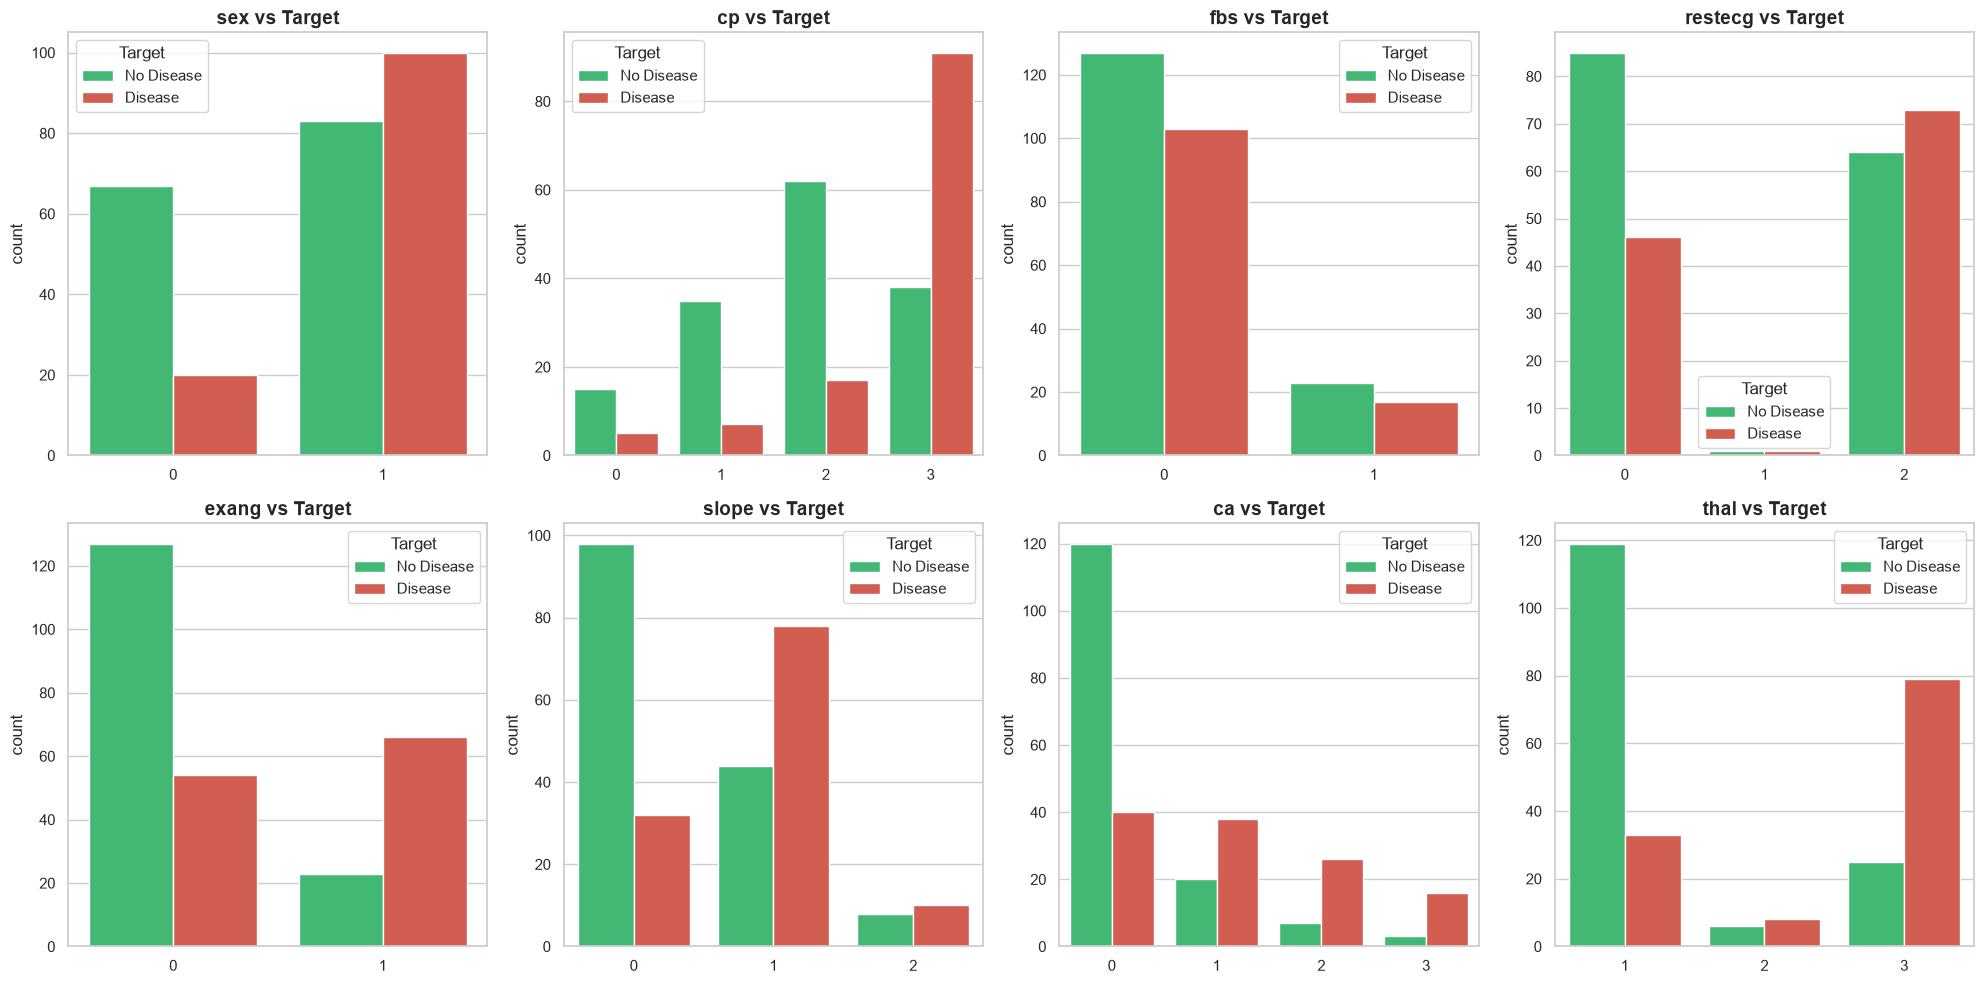

In [3]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue="target", ax=axes[i],
                  palette=["#2ecc71", "#e74c3c"])
    axes[i].set_title(f"{col} vs Target")
    axes[i].legend(title="Target", labels=["No Disease", "Disease"])
    axes[i].set_xlabel("")

plt.tight_layout()
plt.savefig("../reports/figures/07_categorical_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
for col in cat_cols:
    print(f"\n===== {col} =====")
    ct = pd.crosstab(df[col], df["target"], normalize="index") * 100
    ct.columns = ["No Disease %", "Disease %"]
    print(ct.round(1))


===== sex =====
     No Disease %  Disease %
sex                         
0            77.0       23.0
1            45.4       54.6

===== cp =====
    No Disease %  Disease %
cp                         
0           75.0       25.0
1           83.3       16.7
2           78.5       21.5
3           29.5       70.5

===== fbs =====
     No Disease %  Disease %
fbs                         
0            55.2       44.8
1            57.5       42.5

===== restecg =====
         No Disease %  Disease %
restecg                         
0                64.9       35.1
1                50.0       50.0
2                46.7       53.3

===== exang =====
       No Disease %  Disease %
exang                         
0              70.2       29.8
1              25.8       74.2

===== slope =====
       No Disease %  Disease %
slope                         
0              75.4       24.6
1              36.1       63.9
2              44.4       55.6

===== ca =====
    No Disease %  Disease %
ca 

In [5]:
df["age_bin"] = pd.cut(
    df["age"],
    bins=[0, 40, 50, 60, 70, 100],
    labels=["<=40", "41-50", "51-60", "61-70", "70+"]
)

print(df["age_bin"].value_counts().sort_index())

age_bin
<=40      15
41-50     71
51-60    112
61-70     66
70+        6
Name: count, dtype: int64


  age_bin  total  disease  disease_rate
0    <=40     15        6     40.000000
1   41-50     71       20     28.169014
2   51-60    112       55     49.107143
3   61-70     66       38     57.575758
4     70+      6        1     16.666667


C:\Users\NLP\AppData\Local\Temp\ipykernel_17264\2357095500.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trend, x="age_bin", y="disease_rate", palette="Reds")


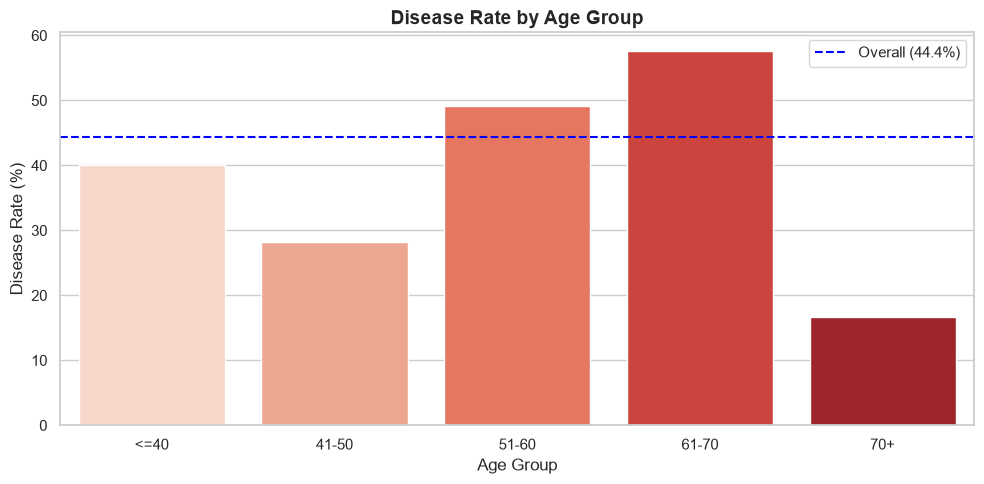

In [6]:
trend = df.groupby("age_bin", observed=True).agg(
    total=("target", "size"),
    disease=("target", "sum")
).reset_index()
trend["disease_rate"] = trend["disease"] / trend["total"] * 100
print(trend)

plt.figure(figsize=(10, 5))
sns.barplot(data=trend, x="age_bin", y="disease_rate", palette="Reds")
plt.title("Disease Rate by Age Group")
plt.ylabel("Disease Rate (%)")
plt.xlabel("Age Group")
plt.axhline(df["target"].mean() * 100, color="blue",
            linestyle="--", label=f"Overall ({df['target'].mean()*100:.1f}%)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/08_disease_rate_by_age.png", dpi=150, bbox_inches="tight")
plt.show()

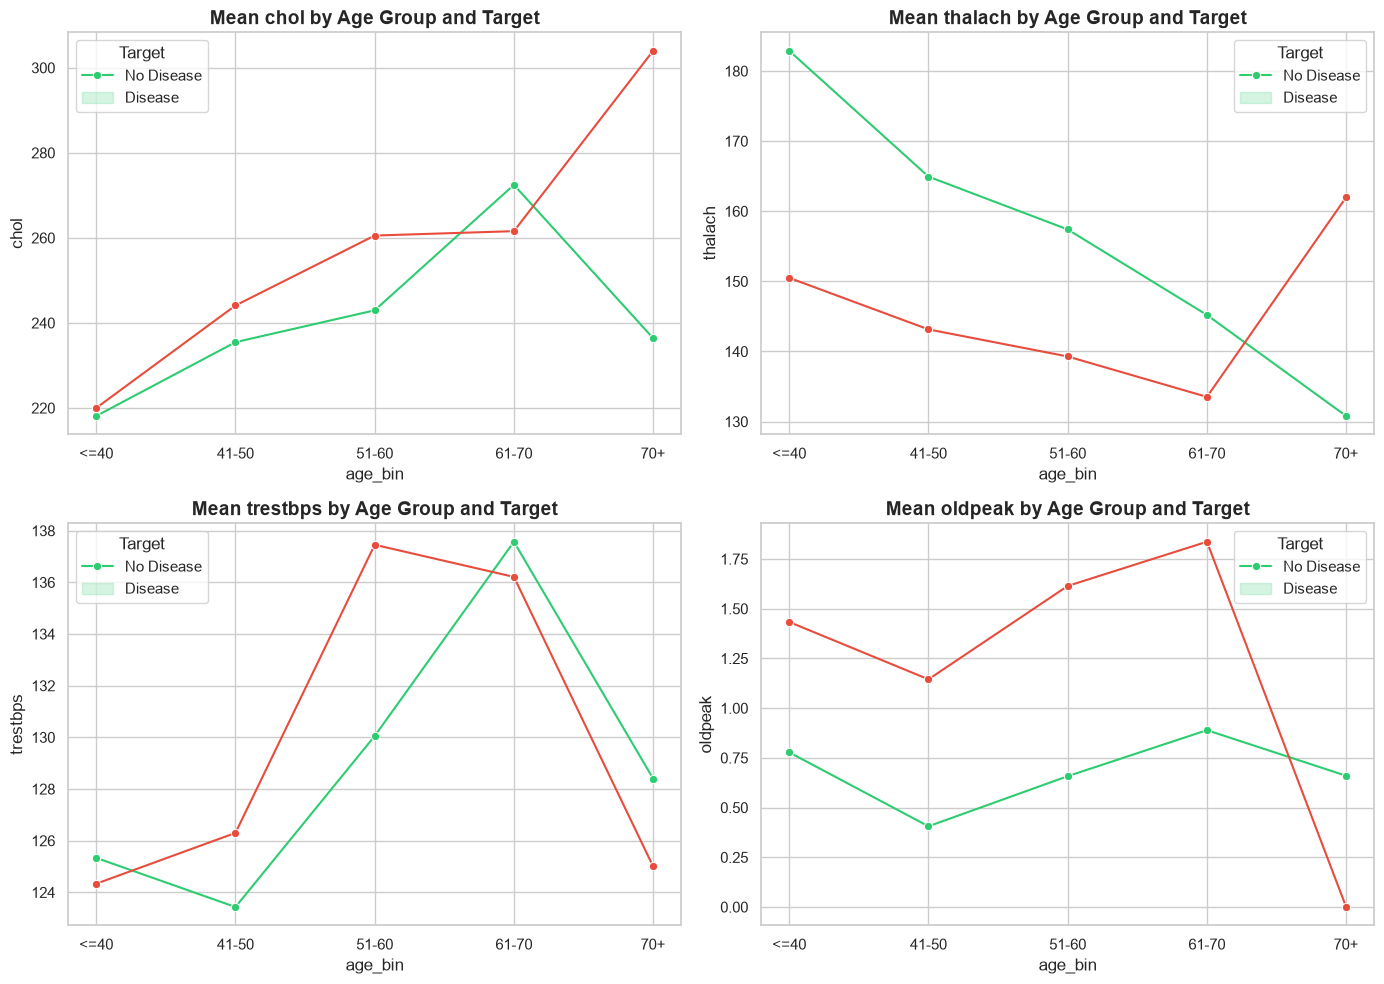

In [7]:
trend2 = df.groupby(["age_bin", "target"], observed=True)[
    ["chol", "thalach", "trestbps", "oldpeak"]
].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(["chol", "thalach", "trestbps", "oldpeak"]):
    sns.lineplot(data=trend2, x="age_bin", y=col, hue="target",
                 marker="o", ax=axes[i], palette=["#2ecc71", "#e74c3c"])
    axes[i].set_title(f"Mean {col} by Age Group and Target")
    axes[i].legend(title="Target", labels=["No Disease", "Disease"])

plt.tight_layout()
plt.savefig("../reports/figures/09_trends_by_age.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
from scipy.signal import find_peaks

def histogram_peaks(series, bins=20, prominence=1):
    hist, edges = np.histogram(series.dropna(), bins=bins)
    peaks, props = find_peaks(hist, prominence=prominence)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers[peaks], hist[peaks]

for col in numeric_cols:
    centers, heights = histogram_peaks(df[col], bins=20, prominence=2)
    print(f"\n--- {col} peaks ---")
    for c, h in zip(centers, heights):
        print(f"  value ≈ {c:.1f}, count = {h}")


--- age peaks ---
  value ≈ 35.0, count = 5
  value ≈ 42.2, count = 24
  value ≈ 54.2, count = 29
  value ≈ 59.0, count = 39
  value ≈ 66.2, count = 22

--- trestbps peaks ---
  value ≈ 117.8, count = 42
  value ≈ 128.4, count = 44
  value ≈ 139.1, count = 39
  value ≈ 149.7, count = 22
  value ≈ 160.2, count = 12
  value ≈ 176.2, count = 3

--- chol peaks ---
  value ≈ 224.6, count = 47
  value ≈ 399.8, count = 3

--- thalach peaks ---
  value ≈ 139.8, count = 24
  value ≈ 159.4, count = 39
  value ≈ 172.5, count = 28

--- oldpeak peaks ---
  value ≈ 1.1, count = 28
  value ≈ 1.7, count = 21


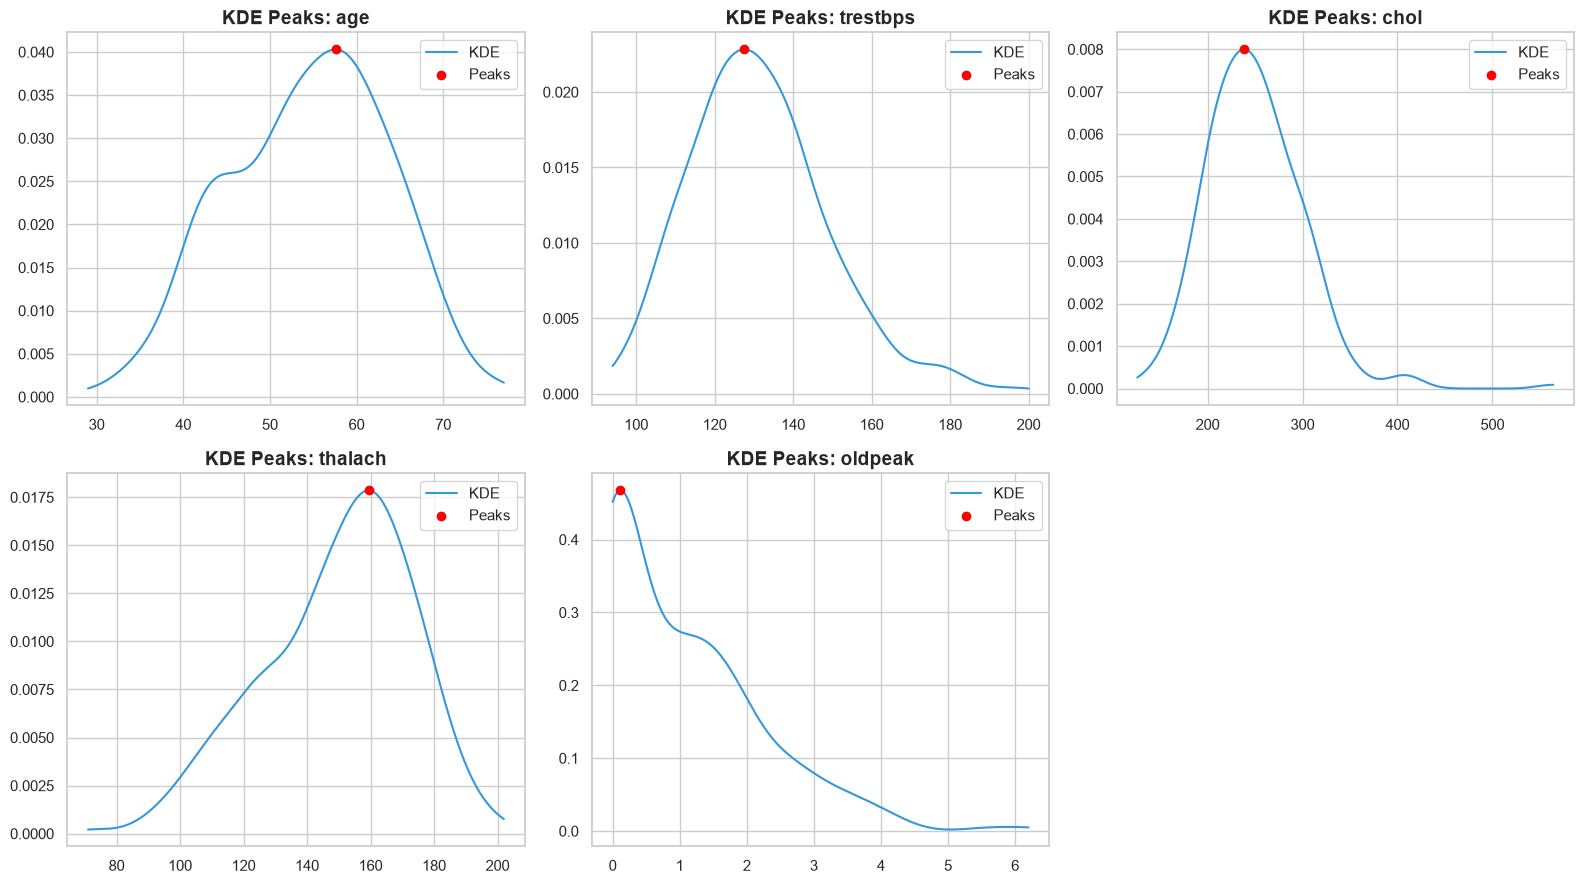

In [9]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    x = np.linspace(df[col].min(), df[col].max(), 500)
    kde = gaussian_kde(df[col])
    y = kde(x)
    peaks, _ = find_peaks(y, prominence=0.005)

    axes[i].plot(x, y, color="#3498db", label="KDE")
    axes[i].scatter(x[peaks], y[peaks], color="red", zorder=5, label="Peaks")
    axes[i].set_title(f"KDE Peaks: {col}")
    axes[i].legend()

fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig("../reports/figures/10_kde_peaks.png", dpi=150, bbox_inches="tight")
plt.show()

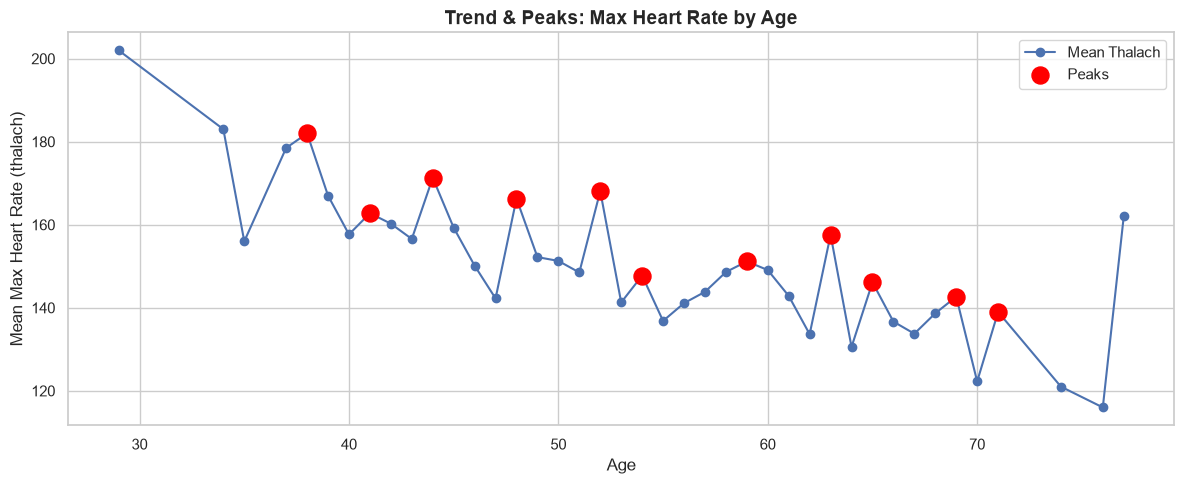

Peak ages: [38, 41, 44, 48, 52, 54, 59, 63, 65, 69, 71]
Peak values: [np.float64(182.0), np.float64(162.77777777777777), np.float64(171.3), np.float64(166.28571428571428), np.float64(168.0909090909091), np.float64(147.75), np.float64(151.16666666666666), np.float64(157.57142857142858), np.float64(146.125), np.float64(142.66666666666666), np.float64(139.0)]


In [10]:
age_trend = df.groupby("age")["thalach"].mean()
peaks, _ = find_peaks(age_trend.values, prominence=5)

plt.figure(figsize=(12, 5))
plt.plot(age_trend.index, age_trend.values, marker="o", label="Mean Thalach")
plt.scatter(age_trend.index[peaks], age_trend.values[peaks],
            color="red", s=150, zorder=5, label="Peaks")
plt.xlabel("Age")
plt.ylabel("Mean Max Heart Rate (thalach)")
plt.title("Trend & Peaks: Max Heart Rate by Age")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/11_thalach_trend_peaks.png", dpi=150, bbox_inches="tight")
plt.show()

print("Peak ages:", list(age_trend.index[peaks]))
print("Peak values:", list(age_trend.values[peaks]))


In [11]:
from scipy.stats import ttest_ind, mannwhitneyu

print(f"{'Feature':<12} {'t-stat':>10} {'t-p':>12} {'U-p':>12} {'Significant?':>15}")
print("-" * 65)

for col in numeric_cols:
    g0 = df[df["target"] == 0][col]
    g1 = df[df["target"] == 1][col]
    t_stat, t_p = ttest_ind(g0, g1, equal_var=False)
    u_stat, u_p = mannwhitneyu(g0, g1)
    sig = "YES ✅" if t_p < 0.05 else "no"
    print(f"{col:<12} {t_stat:>10.3f} {t_p:>12.6f} {u_p:>12.6f} {sig:>15}")

Feature          t-stat          t-p          U-p    Significant?
-----------------------------------------------------------------
age              -3.620     0.000353     0.000205           YES ✅
trestbps         -2.533     0.011960     0.031541           YES ✅
chol             -1.972     0.049707     0.007701           YES ✅
thalach           7.394     0.000000     0.000000           YES ✅
oldpeak          -7.172     0.000000     0.000000           YES ✅


In [12]:
from scipy.stats import chi2_contingency

print(f"{'Feature':<12} {'chi2':>10} {'p-value':>12} {'dof':>5} {'Significant?':>15}")
print("-" * 60)

for col in cat_cols:
    table = pd.crosstab(df[col], df["target"])
    chi2, p, dof, expected = chi2_contingency(table)
    sig = "YES ✅" if p < 0.05 else "no"
    print(f"{col:<12} {chi2:>10.3f} {p:>12.6f} {dof:>5} {sig:>15}")

Feature            chi2      p-value   dof    Significant?
------------------------------------------------------------
sex              22.667     0.000002     1           YES ✅
cp               68.588     0.000000     3           YES ✅
fbs               0.009     0.923706     1              no
restecg           8.979     0.011224     2           YES ✅
exang            45.692     0.000000     1           YES ✅
slope            40.370     0.000000     2           YES ✅
ca               62.863     0.000000     3           YES ✅
thal             74.569     0.000000     2           YES ✅


In [13]:
print("=" * 60)
print("SIGNIFICANT FEATURES (p < 0.05)")
print("=" * 60)

print("\n📊 Numeric features (T-test):")
for col in numeric_cols:
    g0 = df[df["target"] == 0][col]
    g1 = df[df["target"] == 1][col]
    t_stat, t_p = ttest_ind(g0, g1, equal_var=False)
    if t_p < 0.05:
        print(f"  ✅ {col}: mean No Disease = {g0.mean():.1f}, "
              f"Disease = {g1.mean():.1f}, p = {t_p:.2e}")

print("\n📊 Categorical features (Chi-square):")
for col in cat_cols:
    table = pd.crosstab(df[col], df["target"])
    chi2, p, _, _ = chi2_contingency(table)
    if p < 0.05:
        print(f"  ✅ {col}: p = {p:.2e}")

SIGNIFICANT FEATURES (p < 0.05)

📊 Numeric features (T-test):
  ✅ age: mean No Disease = 52.7, Disease = 56.6, p = 3.53e-04
  ✅ trestbps: mean No Disease = 128.9, Disease = 134.4, p = 1.20e-02
  ✅ chol: mean No Disease = 244.2, Disease = 256.5, p = 4.97e-02
  ✅ thalach: mean No Disease = 158.3, Disease = 138.9, p = 2.60e-12
  ✅ oldpeak: mean No Disease = 0.6, Disease = 1.6, p = 1.60e-11

📊 Categorical features (Chi-square):
  ✅ sex: p = 1.93e-06
  ✅ cp: p = 8.56e-15
  ✅ restecg: p = 1.12e-02
  ✅ exang: p = 1.38e-11
  ✅ slope: p = 1.71e-09
  ✅ ca: p = 1.44e-13
  ✅ thal: p = 6.42e-17


In [14]:
# Summary stats by target
summary = df.groupby("target")[numeric_cols].agg(["mean", "median", "std"]).round(2)
summary.to_csv("../reports/eda_summary_by_target.csv")
print("Saved: reports/eda_summary_by_target.csv")
print(summary)

Saved: reports/eda_summary_by_target.csv
          age              trestbps                  chol                \
         mean median   std     mean median    std    mean median    std   
target                                                                    
0       52.71   52.0  9.51   128.87  130.0  16.46  244.21  236.0  54.02   
1       56.59   58.0  8.12   134.44  130.0  19.10  256.47  255.5  47.97   

       thalach               oldpeak               
          mean median    std    mean median   std  
target                                             
0       158.33  161.0  19.28    0.62    0.2  0.80  
1       138.86  141.5  23.13    1.58    1.4  1.28  
